Roof Classification by Raffi Satya Nugraha

#Change Python to 3.9

In [ ]:
!sudo apt-get update -y
!sudo apt-get install python3.9 python3.9-distutils -y

!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.9 1
!sudo update-alternatives --set python3 /usr/bin/python3.9

!wget https://bootstrap.pypa.io/get-pip.py
!python3.9 get-pip.py

!python3.9 --version

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,123 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,825 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,289 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,436 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics

# Install Tensorflow

In [ ]:
!pip install tensorflow==2.12.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.9/585.9 MB 22.4 MB/s  0:00:15
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 150.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 95.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 212.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 171.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 161.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 155.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 106.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 62.5 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 214.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 168.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 59.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 156.1 MB/s  0:00:00
  Attempting unin

#Preparation

In [ ]:
# import necessary libraries
import glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate, Dropout
from tensorflow.keras import Model

from PIL import Image

In [ ]:
# connect google drive
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
# set the working directory
import os
os.chdir(r'/content/gdrive/MyDrive/data_atap/')

## **Data preprocessing**

In [ ]:
import glob

train_x = sorted(glob.glob('train/*_image.png'))
train_y = sorted(glob.glob('train/*_mask.png'))
test_x = sorted(glob.glob('test/*_image.png'))
test_y = sorted(glob.glob('test/*_mask.png'))

print(len(train_x), len(train_y), len(test_x), len(test_y))

def find_unmatched(images, labels):
    img_basenames = [os.path.basename(f).replace('_image.png', '') for f in images]
    lbl_basenames = [os.path.basename(f).replace('_mask.png', '') for f in labels]

    img_only = sorted(set(img_basenames) - set(lbl_basenames))
    lbl_only = sorted(set(lbl_basenames) - set(img_basenames))

    return img_only, lbl_only

train_img_only, train_lbl_only = find_unmatched(train_x, train_y)
test_img_only, test_lbl_only = find_unmatched(test_x, test_y)


1259 1259 274 274
=== TRAIN ===
Tanpa label: []
Tanpa image: []
=== TEST ===
Tanpa label: []
Tanpa image: []


In [ ]:
# converting training image to numpy array
train_xx = np.zeros((1259, 128, 128, 3))
train_yy = np.zeros((1259, 128, 128, 1))
for i, (img, mask) in enumerate(zip(train_x, train_y)):
  img = Image.open(img)
  np_img = np.array(img)
  train_xx[i] = np_img

  mask = Image.open(mask)
  np_mask = np.array(mask).reshape(128, 128, 1)
  train_yy[i] = np_mask

from tensorflow.keras.utils import to_categorical
train_yy = to_categorical(train_yy, num_classes=6)



In [ ]:
# converting testing image to numpy array
test_xx = np.zeros((274, 128, 128, 3))
test_yy = np.zeros((274, 128, 128, 1))
for i, (img, mask) in enumerate(zip(test_x, test_y)):
  img = Image.open(img)
  np_img = np.array(img)
  test_xx[i] = np_img

  mask = Image.open(mask)
  np_mask = np.array(mask).reshape(128, 128, 1)
  test_yy[i] = np_mask

from tensorflow.keras.utils import to_categorical
test_yy = to_categorical(test_yy, num_classes=6)


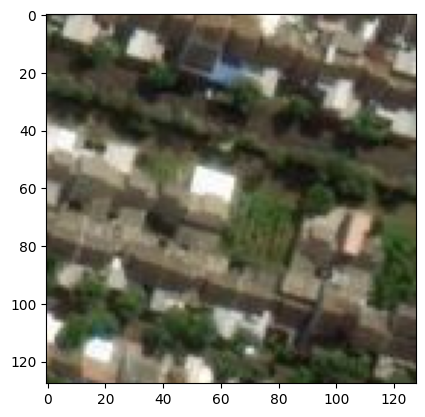

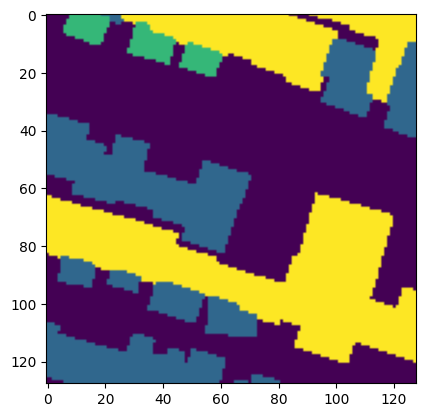

In [ ]:
# Let's plot a sample input RGB image and output image with buildings

plt.imshow(train_xx[200, :, :, :].astype('uint8'))
plt.show()

plt.imshow(np.argmax(train_yy[200], axis=-1).astype('uint8'))
plt.show()


## **Save to numpy format**

In [ ]:
train_xx.shape

(1259, 128, 128, 3)

In [ ]:
np.save('train_xx.npy', train_xx)
np.save('train_yy.npy', train_yy)
np.save("test_xx.npy", test_xx)
np.save("test_yy.npy", test_yy)

In [ ]:
# If you want to save npy
# save_dir = "/content/gdrive/MyDrive/data_atap"  # contoh folder


# import os
# os.makedirs(save_dir, exist_ok=True)

# np.save(os.path.join(save_dir, 'train_xx.npy'), train_xx)
# np.save(os.path.join(save_dir, 'train_yy.npy'), train_yy)
# np.save(os.path.join(save_dir, 'test_xx.npy'), test_xx)
# np.save(os.path.join(save_dir, 'test_yy.npy'), test_yy)


In [ ]:
# If you already have npy
# from google.colab import drive
# drive.mount('/content/gdrive')
# import os
# import numpy as np

# load_dir = "/content/gdrive/MyDrive/data_atap"

# train_xx = np.load(os.path.join(load_dir, 'train_xx.npy'))
# train_yy = np.load(os.path.join(load_dir, 'train_yy.npy'))
# test_xx  = np.load(os.path.join(load_dir, 'test_xx.npy'))
# test_yy  = np.load(os.path.join(load_dir, 'test_yy.npy'))

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
print(train_xx.dtype, train_xx.shape)
print(train_yy.dtype, train_yy.shape)

float64 (1259, 128, 128, 3)
float64 (1259, 128, 128, 6)


#U-Net Model

In [ ]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Conv2DTranspose,
    Concatenate, Dropout, BatchNormalization
)
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import tensorflow as tf

# Optional: custom IoU metric
def mean_iou(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1)
    y_true = tf.argmax(y_true, axis=-1)
    metric = tf.keras.metrics.MeanIoU(num_classes=6)
    metric.update_state(y_true, y_pred)
    return metric.result()

# Input
x_in = Input(shape=(128, 128, 3))

# ==== ENCODER ====
x_temp = Conv2D(32, (3, 3), activation='relu', padding='same',
                kernel_regularizer=regularizers.l2(1e-4))(x_in)
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.25)(x_temp)
x_skip1 = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
x_skip1 = BatchNormalization()(x_skip1)
x_temp = MaxPooling2D((2, 2))(x_skip1)

x_temp = Conv2D(64, (3, 3), activation='relu', padding='same',
                kernel_regularizer=regularizers.l2(1e-4))(x_temp)
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.25)(x_temp)
x_skip2 = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
x_skip2 = BatchNormalization()(x_skip2)
x_temp = MaxPooling2D((2, 2))(x_skip2)

x_temp = Conv2D(128, (3, 3), activation='relu', padding='same',
                kernel_regularizer=regularizers.l2(1e-4))(x_temp)
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.3)(x_temp)
x_skip3 = Conv2D(128, (3, 3), activation='relu', padding='same')(x_temp)
x_skip3 = BatchNormalization()(x_skip3)
x_temp = MaxPooling2D((2, 2))(x_skip3)

# ==== BOTTLENECK ====
x_temp = Conv2D(256, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.4)(x_temp)
x_temp = Conv2D(256, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = BatchNormalization()(x_temp)

# ==== DECODER ====
x_temp = Conv2DTranspose(128, (3, 3), strides=(2, 2), activation='relu', padding='same')(x_temp)
x_temp = Concatenate()([x_temp, x_skip3])
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.3)(x_temp)

x_temp = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu', padding='same')(x_temp)
x_temp = Concatenate()([x_temp, x_skip2])
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.3)(x_temp)

x_temp = Conv2DTranspose(32, (3, 3), strides=(2, 2), activation='relu', padding='same')(x_temp)
x_temp = Concatenate()([x_temp, x_skip1])
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.25)(x_temp)

# ==== OUTPUT (6 classes) ====
x_out = Conv2D(6, (1, 1), activation='softmax', padding='same')(x_temp)

model = Model(inputs=x_in, outputs=x_out)

# ==== COMPILE ====
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', mean_iou]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ dropout_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ dropout_2[0][0] 

 Total params: 1,657,734 (6.32 MB)

 Trainable params: 1,654,918 (6.31 MB)

 Non-trainable params: 2,816 (11.00 KB)

#Training

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# === CALLBACKS ===
checkpoint = ModelCheckpoint(
    filepath='/content/gdrive/MyDrive/data_atap/modelsnew.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# === KOMPILE ULANG MODEL ===
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',   # untuk multi-class segmentation
    metrics=['accuracy']
)
from tensorflow.keras.utils import to_categorical

# Pastikan label belum dalam bentuk one-hot
if train_yy.ndim == 3:
    train_yy = to_categorical(train_yy, num_classes=6)
if test_yy.ndim == 3:
    test_yy = to_categorical(test_yy, num_classes=6)


print("train_yy shape:", train_yy.shape)
print("test_yy shape:", test_yy.shape)

# === TRAINING ===
history = model.fit(
    train_xx, train_yy,
    validation_data=(test_xx, test_yy),
    epochs=100,
    batch_size=2,   # sesuaikan dengan VRAM
    callbacks=[checkpoint, early_stop],
    verbose=1
)


train_yy shape: (500, 128, 128, 6)
test_yy shape: (100, 128, 128, 6)
Epoch 1/100
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5561 - loss: 1.5041
Epoch 1: val_loss improved from inf to 0.89112, saving model to /content/gdrive/MyDrive/data_atap/modelsnew.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.5574 - loss: 1.4991 - val_accuracy: 0.6793 - val_loss: 0.8911
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6689 - loss: 0.9769
Epoch 2: val_loss improved from 0.89112 to 0.74459, saving model to /content/gdrive/MyDrive/data_atap/modelsnew.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6689 - loss: 0.9766 - val_accuracy: 0.7344 - val_loss: 0.7446
Epoch 3/100
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7103 - loss: 0.8187
Epoch 3: val_loss did not improve from 0.74459
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7103 - loss: 0.8187 - val_accuracy: 0.6727 - val_loss: 0.8795
Epoch 4/100
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7298 - loss: 0.7716
Epoch 4: val_loss did not improve from 0.74459
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7299 - loss: 0.7714 - val_accuracy: 0.7287 - val_loss: 0.7973
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7516 - loss: 0.7216
Epoch 5: val_loss improved from 0.74459 to 0.62600, saving model to /content/gdrive/MyDrive/data_atap/modelsnew.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7517 - loss: 0.7215 - val_accuracy: 0.7665 - val_loss: 0.6260
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7720 - loss: 0.6544
Epoch 6: val_loss did not improve from 0.62600
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7720 - loss: 0.6545 - val_accuracy: 0.7571 - val_loss: 0.6475
Epoch 7/100
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7690 - loss: 0.6708
Epoch 7: val_loss improved from 0.62600 to 0.55073, saving model to /content/gdrive/MyDrive/data_atap/modelsnew.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7692 - loss: 0.6703 - val_accuracy: 0.7953 - val_loss: 0.5507
Epoch 8/100
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7785 - loss: 0.6310
Epoch 8: val_loss did not improve from 0.55073
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7786 - loss: 0.6307 - val_accuracy: 0.7715 - val_loss: 0.6183
Epoch 9/100
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8000 - loss: 0.5812
Epoch 9: val_loss improved from 0.55073 to 0.51314, saving model to /content/gdrive/MyDrive/data_atap/modelsnew.h5


...

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9599 - loss: 0.1206 - val_accuracy: 0.9679 - val_loss: 0.0955
Epoch 73/100
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9588 - loss: 0.1248
Epoch 73: val_loss did not improve from 0.09553
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9588 - loss: 0.1248 - val_accuracy: 0.9636 - val_loss: 0.1073
Epoch 74/100
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9567 - loss: 0.1313
Epoch 74: val_loss did not improve from 0.09553
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9567 - loss: 0.1313 - val_accuracy: 0.9664 - val_loss: 0.1003
Epoch 75/100
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9592 - loss: 0.1228
Epoch 75: val_loss did not improve from 0.09553
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9592 - loss: 0.1228 - val_accuracy: 0.9676 - val_loss: 0.0967
Epoch 76/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9612 - loss: 0.1168
Epoch 76: val_loss did not i

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9534 - loss: 0.1427 - val_accuracy: 0.9694 - val_loss: 0.0946
Epoch 79/100
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9600 - loss: 0.1209
Epoch 79: val_loss did not improve from 0.09462
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9600 - loss: 0.1209 - val_accuracy: 0.9690 - val_loss: 0.0958
Epoch 80/100
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9377 - loss: 0.2005
Epoch 80: val_loss did not improve from 0.09462
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9378 - loss: 0.2002 - val_accuracy: 0.9648 - val_loss: 0.1068
Epoch 81/100
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9599 - loss: 0.1240
Epoch 81: val_loss did not improve from 0.09462
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9599 - loss: 0.1240 - val_accuracy: 0.9685 - val_loss: 0.0970
Epoch 82/100
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9599 - loss: 0.1235
Epoch 82: val_loss did not i

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9594 - loss: 0.1235 - val_accuracy: 0.9718 - val_loss: 0.0862
Epoch 86/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9619 - loss: 0.1146
Epoch 86: val_loss did not improve from 0.08616
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9619 - loss: 0.1146 - val_accuracy: 0.9408 - val_loss: 0.1705
Epoch 87/100
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9579 - loss: 0.1278
Epoch 87: val_loss did not improve from 0.08616
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9579 - loss: 0.1280 - val_accuracy: 0.9662 - val_loss: 0.1031
Epoch 88/100
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9593 - loss: 0.1255
Epoch 88: val_loss did not improve from 0.08616
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9593 - loss: 0.1255 - val_accuracy: 0.9700 - val_loss: 0.0917
Epoch 89/100
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9631 - loss: 0.1116
Epoch 89: val_loss did not i

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9617 - loss: 0.1169 - val_accuracy: 0.9728 - val_loss: 0.0852
Epoch 95/100
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9642 - loss: 0.1092
Epoch 95: val_loss improved from 0.08519 to 0.07997, saving model to /content/gdrive/MyDrive/data_atap/modelsnew.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9642 - loss: 0.1092 - val_accuracy: 0.9743 - val_loss: 0.0800
Epoch 96/100
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9641 - loss: 0.1082
Epoch 96: val_loss did not improve from 0.07997
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9641 - loss: 0.1082 - val_accuracy: 0.9738 - val_loss: 0.0809
Epoch 97/100
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9633 - loss: 0.1102
Epoch 97: val_loss did not improve from 0.07997
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9634 - loss: 0.1102 - val_accuracy: 0.9728 - val_loss: 0.0832
Epoch 98/100
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9665 - loss: 0.1008
Epoch 98: val_loss did not improve from 0.07997
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9665 - loss: 0.1009 - val_accuracy: 0.9697 - val_loss: 0.0953
Epoch 99/100
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9644 - loss: 0.1076
Epoch 99: val_loss did not i

#Plot Accuracy & Loss

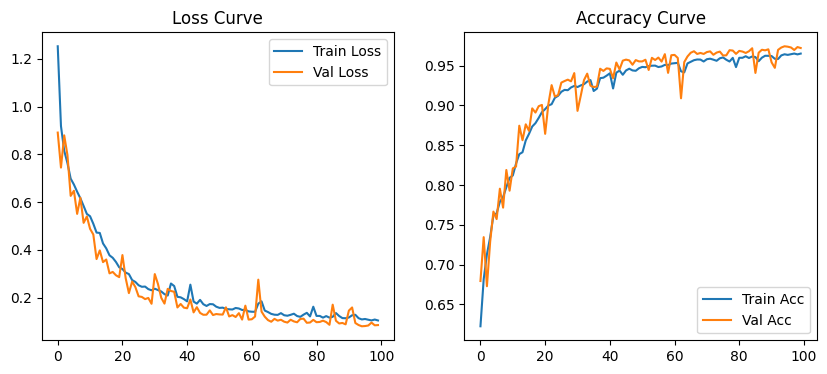

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss Curve')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Accuracy Curve')
plt.show()


#Check Samples Results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


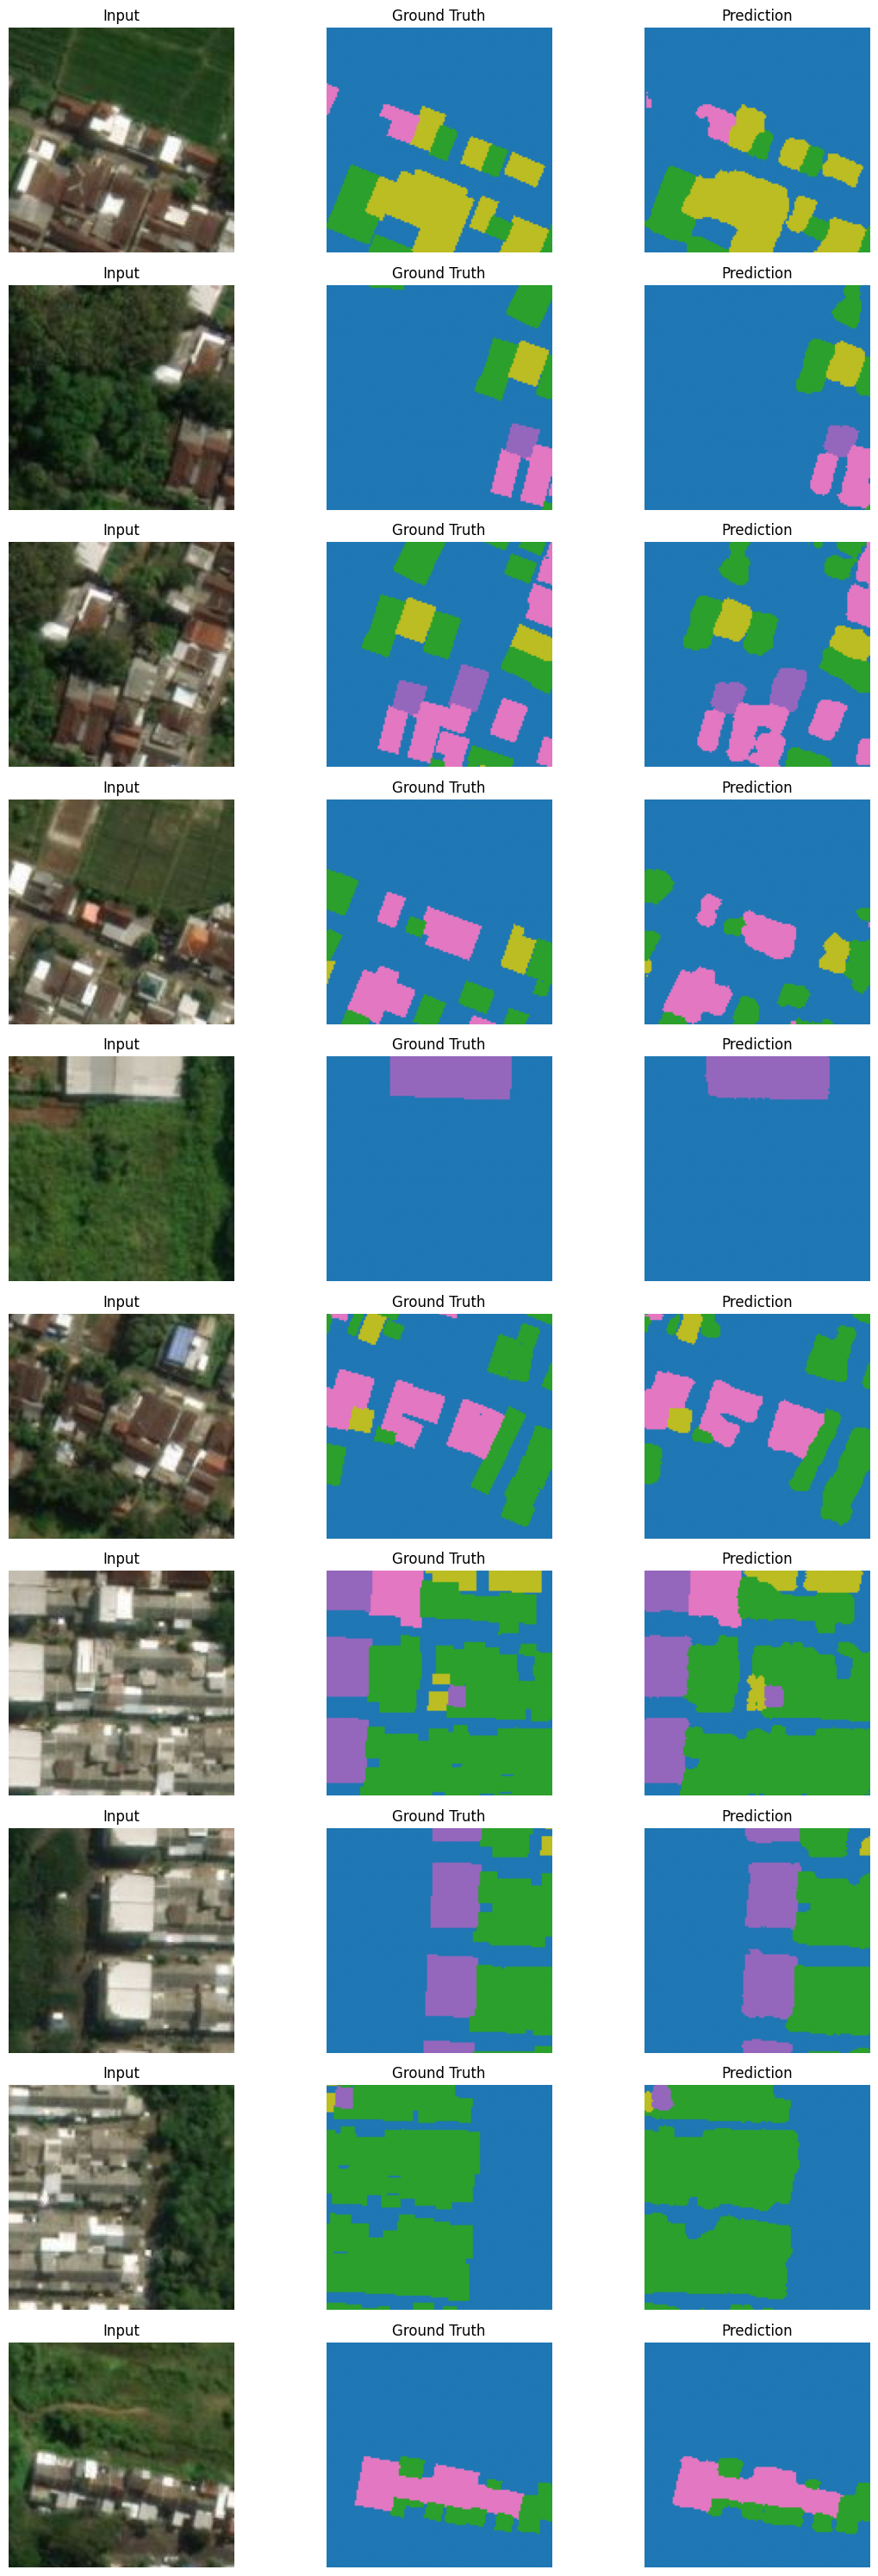

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sample_x = np.array(test_xx[:10])
sample_y_true = np.array(test_yy[:10])

y_pred = model.predict(sample_x)
y_pred_argmax = np.argmax(y_pred, axis=-1)
y_true_argmax = np.argmax(sample_y_true, axis=-1)

x_vis = sample_x.copy().astype('float32')
if x_vis.max() > 1:
    x_vis /= 255.0

fig, axes = plt.subplots(10, 3, figsize=(12, 30))
for i in range(10):
    axes[i, 0].imshow(x_vis[i])
    axes[i, 0].set_title("Input")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(y_true_argmax[i], cmap='tab20', vmin=0, vmax=5)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(y_pred_argmax[i], cmap='tab20', vmin=0, vmax=5)
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
test_yy = test_yy.astype('uint8')
pred_test = pred_test.astype('uint8')

In [ ]:
def calculate_metrics(ground_truth, predicted_mask):
    # Flatten the binary masks to 1D arrays
    ground_truth = ground_truth.ravel()
    predicted_mask = predicted_mask.ravel()

    # True Positives, False Positives, False Negatives
    TP = np.sum((ground_truth == 1) & (predicted_mask == 1))
    FP = np.sum((ground_truth == 0) & (predicted_mask == 1))
    FN = np.sum((ground_truth == 1) & (predicted_mask == 0))

    # True Negatives (optional, may not be needed for all cases)
    TN = np.sum((ground_truth == 0) & (predicted_mask == 0))

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1_score = 2 * (precision * recall) / (precision + recall)

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN)

    return precision, recall, f1_score, iou

In [ ]:
print(calculate_metrics(test_yy, pred_test))

(0.8668725128857868, 0.9033016203847093, 0.8847122221924824, 0.7932591388490682)
